# 상대국–품목 이분 네트워크 분석 — 논문 결과 재현 노트북

이 노트북은 논문 본문에 인용된 결과·그림·표를 재현한다. 탐색·진단 과정은 제외하고
최종 산출에 필요한 셀만 담았다.

**환경**: conda env `kcsdb`, Python 3.12, DuckDB 1.5.4
**자료**: KCSDB2 (`data/processed/kcsdb.duckdb`), fact_trade, 2007.01–2026.03

**산출물** (그림·표 번호는 논문 MD의 등장 순서를 따름)
- 그림 1: 네트워크 규모 성장 (net_growth)
- 그림 2: 코어 금액/개수 비중 (net_core_share)
- 그림 3: 반도체 목적지 금액점유 이동 (semi_destinations)
- 그림 4: 반도체 이분 네트워크 스냅숏 2025.12 (semi_bipartite)
- 표 1: 코어 내부 금액집중 (상위 1/5/10%) — 논문 V.1절
- 표 2: 반도체 코어/프린지 분류 (2025) — 논문 VI.3절
- (본문 표 아님) 코어 저하 진단 — 논문 §III.4의 서술 근거로만 사용

그림은 600dpi로 저장하며, 글자 크기는 인쇄 축소를 감안해 화면보다 크게 잡았다.
표와 그림이 같은 내용을 다루는 경우 하나만 산출한다. 그림 셀은 번호 순서로 배치했다.
표는 계산 의존성 때문에 산출 순서가 번호 순서와 다르다(코어 저하 진단은 본문 표가 아니라 §III.4 근거다).


## 0. 설정과 자료 로딩

In [1]:
import os
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 (Windows). 환경에 맞게 조정.
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False   # U+2212 tofu 방지 -> ASCII '-'
mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['savefig.dpi'] = 600            # 학술지 제출 기준(선화 600dpi)
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.05
# 글자 크기 — 인쇄 축소를 감안해 화면보다 크게 잡는다
mpl.rcParams['font.size']       = 13
mpl.rcParams['axes.labelsize']  = 13.5
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12.5
mpl.rcParams['axes.linewidth']  = 0.9
mpl.rcParams['lines.linewidth'] = 1.7

# ---- 방법론 확정 상수 (논문 3절) ----
EDGE_MIN = 1000        # 엣지 활성 임계값 ($)
CORE_K   = 11          # 구조적 코어: 최근 12개월 중 >=11
FRINGE_K = 3           # 간헐 프린지: <=3
FIG_DIR  = "img"       # 문서(MD)가 참조하는 그림 폴더
TAB_DIR  = "outputs"   # 표 CSV 저장 폴더
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

def style_ax(ax):
    """흑백 그림 표준: top/right spine 제거, grid 0.87, 눈금 길이 확보."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, color='0.87', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=4, width=0.9)

def find_db():
    here = os.getcwd()
    for _ in range(6):
        p = os.path.join(here, "data/processed/kcsdb.duckdb")
        if os.path.exists(p): return p
        here = os.path.dirname(here)
    p = r"C:\Work\Projects\KCSDB2\data\processed\kcsdb.duckdb"
    if os.path.exists(p): return p
    raise FileNotFoundError("kcsdb.duckdb 미발견")

DB = find_db()
print("DB:", DB)

DB: C:\Work\Projects\KCSDB2\data/processed/kcsdb.duckdb


## 0.5 그림 1 — 이분 네트워크 개념도

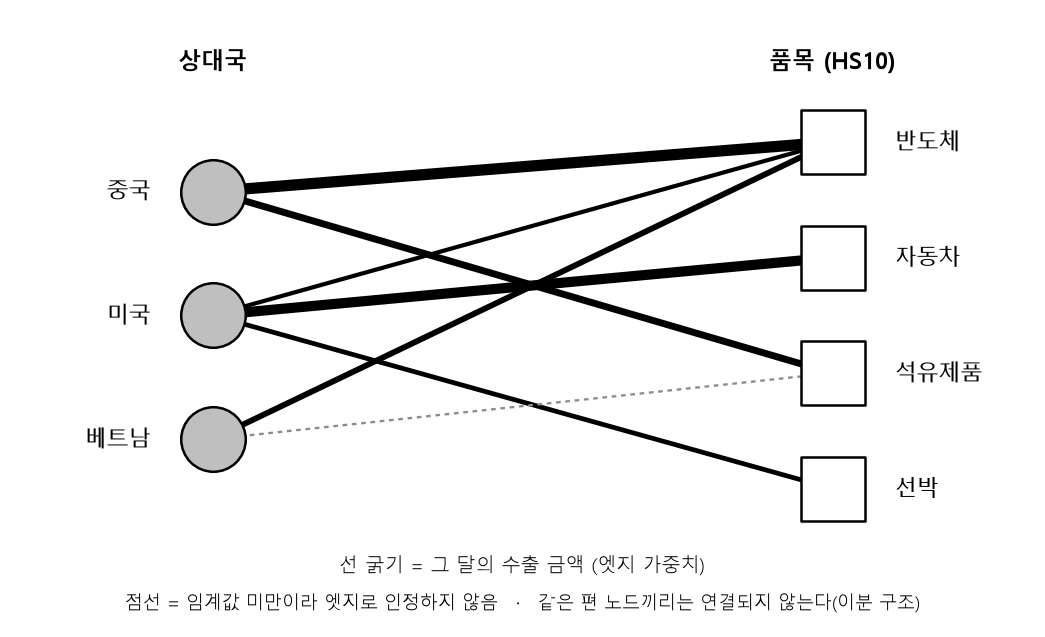

In [2]:
# 그림 1 — 이분 네트워크 개념도 (모식도, 데이터 아님)
# 규격: 그림 6(semi_bipartite)과 맞춤 — 노드 라벨 13, 머리표지 14 bold, 주석 11.5/11
_countries = ['중국','미국','베트남']
_products  = ['반도체','자동차','석유제품','선박']
_lx, _rx = 0.20, 0.80
_cy = np.linspace(0.70, 0.30, len(_countries))
_py = np.linspace(0.78, 0.22, len(_products))
# (국가idx, 품목idx, 가중치, 활성여부) — 개념 설명용 예시 값
_edges = [(0,0,9.0,True),(0,2,5.0,True),(1,1,8.0,True),
          (1,0,2.5,True),(1,3,3.0,True),(2,0,4.0,True),(2,2,0.6,False)]

fig, ax = plt.subplots(figsize=(9.0, 5.6))
for ci, pi, w, act in _edges:
    if act:
        ax.plot([_lx,_rx],[_cy[ci],_py[pi]], color='black', lw=0.9+w*0.65,
                solid_capstyle='round', zorder=1)
    else:
        ax.plot([_lx,_rx],[_cy[ci],_py[pi]], color='0.55', lw=1.4,
                ls=(0,(2,2)), zorder=1)
ax.scatter([_lx]*len(_countries), _cy, s=1500, marker='o', facecolor='0.75',
           edgecolor='black', linewidth=1.5, zorder=2)
ax.scatter([_rx]*len(_products), _py, s=1500, marker='s', facecolor='white',
           edgecolor='black', linewidth=1.5, zorder=2)
for _n,_y in zip(_countries,_cy): ax.text(_lx-0.06,_y,_n,ha='right',va='center',fontsize=13)
for _n,_y in zip(_products,_py):  ax.text(_rx+0.06,_y,_n,ha='left', va='center',fontsize=13)
ax.text(_lx, 0.91, '상대국', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(_rx, 0.91, '품목 (HS10)', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(0.5, 0.085, '선 굵기 = 그 달의 수출 금액 (엣지 가중치)', ha='center', fontsize=11.5)
ax.text(0.5, 0.025, '점선 = 임계값 미만이라 엣지로 인정하지 않음   ·   같은 편 노드끼리는 연결되지 않는다(이분 구조)',
        ha='center', fontsize=11)
ax.set_xlim(0,1); ax.set_ylim(-0.01,1.0); ax.axis('off')
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/net_schematic.png", bbox_inches='tight'); plt.show()

## 1. 월별 엣지 집계

사실표에서 (월, 상대국, 품목) 단위로 수출 금액을 집계하고 임계값을 적용한다.
수출은 `exp_dlr` 열을 사용한다(수출입 구분 열 없음). 결과를 메모리에 올려
이후 모든 지표 계산에 재사용한다.

In [3]:
con = duckdb.connect(DB, read_only=True)
edf = con.execute(f"""
    SELECT yyyymm AS ym, stat_cd AS cty, hs10 AS hs, SUM(exp_dlr) AS v
    FROM fact_trade
    GROUP BY 1,2,3
    HAVING SUM(exp_dlr) > {EDGE_MIN}
""").fetchdf()
cmap = dict(con.execute("SELECT stat_cd, name_ko_kcs FROM dim_country").fetchall())
con.close()

edf['ym'] = edf['ym'].astype(int)
edf['hs'] = edf['hs'].astype(str)
edf['edge'] = list(zip(edf['cty'], edf['hs']))

edge_sets = {ym: set(g['edge']) for ym, g in edf.groupby('ym')}
val_maps  = {ym: dict(zip(g['edge'], g['v'])) for ym, g in edf.groupby('ym')}
by_month  = {ym: g for ym, g in edf.groupby('ym')}
MONTHS = sorted(edge_sets)
print(f"엣지행 {len(edf):,} / 개월 {len(MONTHS)} ({MONTHS[0]}~{MONTHS[-1]})")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

엣지행 14,846,848 / 개월 231 (200701~202603)


## 1.5 §III.1 임계값 민감도

엣지 활성 임계값(0 / 1,000 / 100,000달러) 선택이 규모·금액·집중도 지표를 얼마나 바꾸는지
특정 월(2025·2015년 12월)에서 점검한다. 임계값이 달라도 상위 5국 점유율 등 집중도가
거의 불변임을 보인다(논문 III.1절).

In [4]:
# §III.1 임계값 민감도 — 특정 월을 임계값 0/1,000/100,000달러로 구성해 비교
# (edf는 이미 >1,000 적용본이라, DB에서 임계값 무관 월 스냅샷을 다시 읽는다)
_c = duckdb.connect(DB, read_only=True)
_sens = []
for _m in (202512, 201512):
    _g = _c.execute(f"SELECT stat_cd cty, hs10 hs, SUM(exp_dlr) v "
                    f"FROM fact_trade WHERE yyyymm={_m} GROUP BY 1,2").fetchdf()
    print(f"[{_m}]  임계값별  엣지수 / 총수출(억$) / 상위5국 점유(%) / 엣지 상위1·5·10% 금액점유(%)")
    for _thr in (0, 1000, 100000):
        _s = _g[_g.v > _thr]
        _n = len(_s); _tot = _s.v.sum()
        _cv = _s.groupby('cty')['v'].sum().sort_values(ascending=False)
        _top5 = _cv.iloc[:5].sum()/_cv.sum()*100
        _vals = np.sort(_s.v.values)[::-1]; _N = len(_vals)
        _f = lambda p: _vals[:max(1,int(_N*p))].sum()/_tot*100
        _sens.append({'월':_m, '임계값$':_thr, '엣지수':_n, '총수출_억$':round(_tot/1e8,1),
                      '상위5국_%':round(_top5,1), '엣지상위1_%':round(_f(.01),0),
                      '엣지상위5_%':round(_f(.05),0), '엣지상위10_%':round(_f(.10),0)})
        print(f"  >{_thr:>6}$: {_n:>7,} / {_tot/1e8:>7.1f}억 / {_top5:>4.1f}% / "
              f"{_f(.01):.0f}·{_f(.05):.0f}·{_f(.10):.0f}%")
_c.close()
pd.DataFrame(_sens).to_csv("outputs/sec31_threshold_sensitivity.csv", index=False, encoding='utf-8-sig')

[202512]  임계값별  엣지수 / 총수출(억$) / 상위5국 점유(%) / 엣지 상위1·5·10% 금액점유(%)
  >     0$: 100,724 /   694.8억 / 59.5% / 74·90·95%
  >  1000$:  72,871 /   694.7억 / 59.5% / 70·87·92%
  >100000$:  22,247 /   683.5억 / 60.1% / 58·76·84%
[201512]  임계값별  엣지수 / 총수출(억$) / 상위5국 점유(%) / 엣지 상위1·5·10% 금액점유(%)
  >     0$:  82,878 /   423.7억 / 56.7% / 64·84·91%
  >  1000$:  68,033 /   423.7억 / 56.7% / 61·82·89%
  >100000$:  20,303 /   412.6억 / 57.6% / 48·68·77%


## 2. 공통 함수 (월 이동, 코어 판정, 자카드)

In [5]:
def step(ym, k):
    """ym에서 k개월 뒤로(양수=과거). YYYYMM 정수 연산."""
    y, m = divmod(ym, 100); m -= k
    while m <= 0: y -= 1; m += 12
    while m > 12: y += 1; m -= 12
    return y*100 + m

def last12(ym):
    out, cur = [], ym
    for _ in range(12):
        out.append(cur); cur = step(cur, 1)
    return out

# 층위 판정 결과를 월별로 캐시한다(결정적 함수). 인접 달 판정을 재계산 없이 재사용.
_core_cache = {}; _fringe_cache = {}

def core_at(ym, need=CORE_K):
    """당월 포함 최근 12개월 중 >=need 활성인 엣지 집합. 12개월 미확보 시 None."""
    key = (ym, need)
    if key in _core_cache: return _core_cache[key]
    win = last12(ym)
    if win[-1] not in edge_sets:
        _core_cache[key] = None; return None
    cnt = {}
    for w in win:
        for e in edge_sets.get(w, set()):
            cnt[e] = cnt.get(e, 0) + 1
    res = {e for e, c in cnt.items() if c >= need}
    _core_cache[key] = res; return res

def fringe_at(ym, cap=FRINGE_K):
    key = (ym, cap)
    if key in _fringe_cache: return _fringe_cache[key]
    win = last12(ym)
    if win[-1] not in edge_sets:
        _fringe_cache[key] = None; return None
    cnt = {}
    for w in win:
        for e in edge_sets.get(w, set()):
            cnt[e] = cnt.get(e, 0) + 1
    res = {e for e, c in cnt.items() if c <= cap}
    _fringe_cache[key] = res; return res

def jaccard(a, b):
    if not a and not b: return np.nan
    return len(a & b) / len(a | b)

## 2.5 활성 개월수 분포 (이봉형 — 코어/프린지 경계의 근거)

각 (상대국, 품목) 엣지가 2025년 12개월 중 몇 달 활성인지(월 수출 >$1,000)를 세어 분포를
본다. 분포가 1개월·12개월 양극단에 몰린 이봉형이면, 코어(≥11)와 프린지(≤3)의 경계가
얇은 중간대에 놓여 층위 구분이 자연스럽다(논문 III.3절). 논문의 엣지 정의(>$1,000)를
그대로 적용한다.

In [6]:
# 활성 개월수 분포 (2025년, 월 수출 >$1,000 엣지 기준) — 코어/프린지 경계(11/3)의 이봉형 근거 (논문 III.3절)
from collections import Counter
_cnt = Counter()
for _ym in range(202501, 202513):
    for _e in edge_sets.get(_ym, set()):
        _cnt[_e] += 1
_am  = Counter(_cnt.values())      # 활성개월수 -> 조합 수
_tot = len(_cnt)
print(f"2025년 활성 조합(월 수출 > ${EDGE_MIN:,}) 총수: {_tot:,}")
print("활성개월수 : 조합수 (비율)")
_cum = 0
for k in range(1, 13):
    n = _am.get(k, 0); _cum += n
    tag = ""
    if k == 1:  tag = "  <- 한쪽 봉우리"
    if k == 3:  tag = f"  (<=3개월 누적 {_cum/_tot*100:.1f}%)"
    if k == 12: tag = "  <- 다른 봉우리"
    print(f"  {k:2d}개월 : {n:8,} ({n/_tot*100:4.1f}%){tag}")
_mid = [_am.get(k,0)/_tot*100 for k in range(4,12)]
print(f"중간대(4~11개월) 각 구간: {min(_mid):.1f}~{max(_mid):.1f}% (얇음)")

2025년 활성 조합(월 수출 > $1,000) 총수: 162,932
활성개월수 : 조합수 (비율)
   1개월 :   47,265 (29.0%)  <- 한쪽 봉우리
   2개월 :   21,165 (13.0%)
   3개월 :   13,385 ( 8.2%)  (<=3개월 누적 50.2%)
   4개월 :    9,841 ( 6.0%)
   5개월 :    7,944 ( 4.9%)
   6개월 :    6,432 ( 3.9%)
   7개월 :    5,773 ( 3.5%)
   8개월 :    5,271 ( 3.2%)
   9개월 :    5,193 ( 3.2%)
  10개월 :    5,330 ( 3.3%)
  11개월 :    6,989 ( 4.3%)
  12개월 :   28,344 (17.4%)  <- 다른 봉우리
중간대(4~11개월) 각 구간: 3.2~6.0% (얇음)


## 3. 월별 지표 시계열

각 월에 대해 엣지 수, 밀도, 집중도, 자카드(전체·코어·프린지), 코어 금액/개수 비중을
계산한다. 이 표가 그림 2·3·4의 근거다.

In [7]:
rows = []
for ym in MONTHS:
    g = by_month[ym]
    n_edges = len(g)
    n_cty = g['cty'].nunique(); n_hs = g['hs'].nunique()
    density = n_edges / (n_cty * n_hs)
    total_v = g['v'].sum()
    cty_val = g.groupby('cty')['v'].sum()
    top5 = cty_val.sort_values(ascending=False).iloc[:5].sum() / cty_val.sum()

    core = core_at(ym); fr = fringe_at(ym)
    cur = edge_sets[ym]
    pv = step(ym, 1)
    prev = edge_sets.get(pv, set())
    yoy = edge_sets.get(step(ym, 12), set())

    rec = dict(ym=ym, n_edges=n_edges, density=density,
               export_bil=total_v/1e9, top5_share=top5,
               jac_adj=jaccard(cur, prev) if pv in edge_sets else np.nan,
               jac_yoy=jaccard(cur, yoy) if step(ym,12) in edge_sets else np.nan)
    if core is not None:
        cin = cur & core
        vm = val_maps[ym]; tot = sum(vm.values())
        rec['core_share_edges'] = len(cin)/len(cur)
        rec['core_share_value'] = sum(v for e,v in vm.items() if e in core)/tot
        # 층위 자카드: 각 달의 코어/프린지를 '그 달의' 트레일링 창으로 판정해 비교한다.
        # (당월 창 판정을 직전 달에 소급 적용하면 값이 인위적으로 부풀려진다)
        core_p = core_at(pv); fr_p = fringe_at(pv)
        ok = (pv in edge_sets) and (core_p is not None)
        rec['jac_core']   = jaccard(cin, prev & core_p) if ok else np.nan
        rec['jac_fringe'] = jaccard(cur & fr, prev & fr_p) if ok else np.nan
    rows.append(rec)

ts = pd.DataFrame(rows)
ts['date'] = pd.to_datetime(ts['ym'].astype(str), format='%Y%m')
print(ts[['ym','n_edges','export_bil','core_share_edges','core_share_value',
          'jac_adj','jac_core','jac_fringe']].dropna().describe().round(3))

               ym    n_edges  export_bil  core_share_edges  core_share_value  \
count     219.000    219.000     219.000           219.000           219.000   
mean   201669.452  64969.772      47.080             0.447             0.843   
std       528.056   5884.752       8.711             0.030             0.058   
min    200801.000  45086.000      21.122             0.359             0.637   
25%    201207.500  62161.500      42.347             0.426             0.814   
50%    201702.000  66808.000      46.642             0.448             0.860   
75%    202108.500  69139.500      51.866             0.470             0.887   
max    202603.000  74956.000      86.577             0.518             0.923   

       jac_adj  jac_core  jac_fringe  
count  219.000   219.000     219.000  
mean     0.520     0.916       0.067  
std      0.018     0.016       0.019  
min      0.442     0.819       0.038  
25%      0.511     0.912       0.060  
50%      0.525     0.920       0.063  
75%   

**본문 인용 수치 확인**: 코어 개수/금액 비중, 3층 자카드 평균, 계절성 점검.

In [8]:
v = ts.dropna(subset=['jac_core'])
print(f"코어 개수비중 평균 {v['core_share_edges'].mean()*100:.1f}%")
print(f"코어 금액비중 평균 {v['core_share_value'].mean()*100:.1f}%")
print(f"자카드 전체  {v['jac_adj'].mean():.3f}")
print(f"자카드 코어  {v['jac_core'].mean():.3f}")
print(f"자카드 프린지 {v['jac_fringe'].mean():.3f}")
print(f"자카드 전년동월 {v['jac_yoy'].mean():.3f}")

# 계절성: 월별 인접월 자카드 평균 (본문 한 문장 근거, 그림 없음)
ts['mon'] = ts['ym'] % 100
print("\n월별 인접월 자카드(계절성 점검):")
print(ts.dropna(subset=['jac_adj']).groupby('mon')['jac_adj'].mean().round(3).to_string())

코어 개수비중 평균 44.7%
코어 금액비중 평균 84.3%
자카드 전체  0.520
자카드 코어  0.916
자카드 프린지 0.067
자카드 전년동월 0.482

월별 인접월 자카드(계절성 점검):
mon
1     0.505
2     0.517
3     0.520
4     0.522
5     0.523
6     0.521
7     0.522
8     0.520
9     0.520
10    0.522
11    0.522
12    0.520


## 4. 그림 2 — 네트워크 규모 성장

활성 엣지 수(좌축)와 월 수출액(우축)의 시계열. 두 값은 척도가 달라 이중축으로
표시하되, 본문은 동조의 강도가 아니라 같은 방향의 성장만 서술한다.

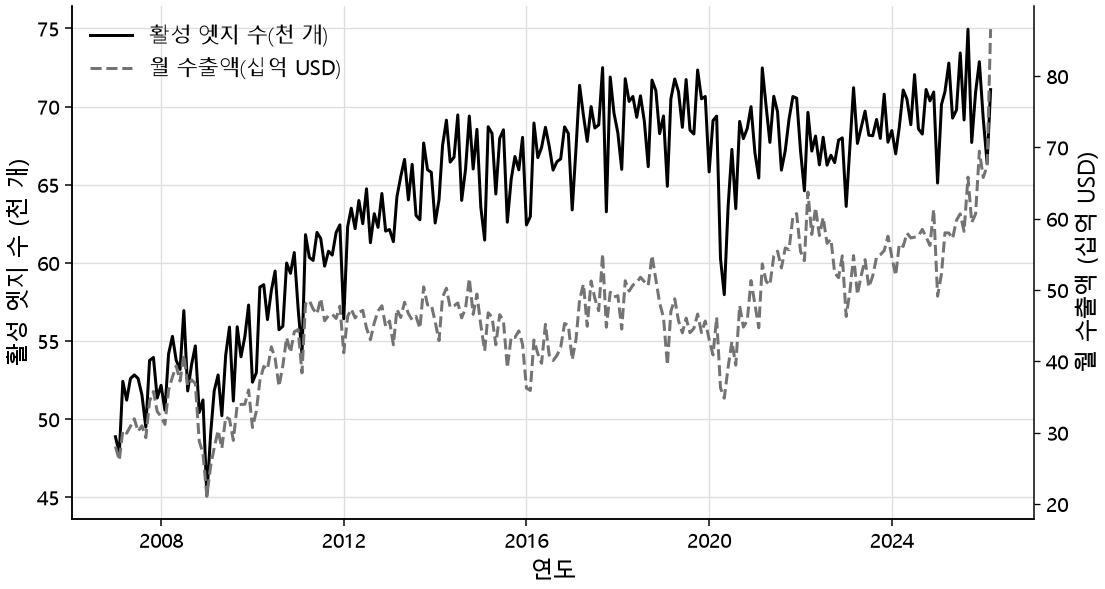

In [9]:
fig, ax1 = plt.subplots(figsize=(9.5, 5.2))
ax1.plot(ts['date'], ts['n_edges']/1000, color='black', lw=1.8,
         label='활성 엣지 수(천 개)')
ax1.set_ylabel('활성 엣지 수 (천 개)')
ax1.set_xlabel('연도')
ax2 = ax1.twinx()
ax2.plot(ts['date'], ts['export_bil'], color='0.45', lw=1.8, ls='--',
         label='월 수출액(십억 USD)')
ax2.set_ylabel('월 수출액 (십억 USD)')
style_ax(ax1)                              # top/right 제거 + grid 0.87
ax2.spines['top'].set_visible(False)       # 우축은 살리고 top만 제거
# 제목은 본문 캡션과 중복되므로 그림에 넣지 않는다
l1,lab1 = ax1.get_legend_handles_labels(); l2,lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lab1+lab2, loc='upper left', frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/net_growth.png"); plt.show()

## 5. 그림 3 — 층위별 인접월 자카드

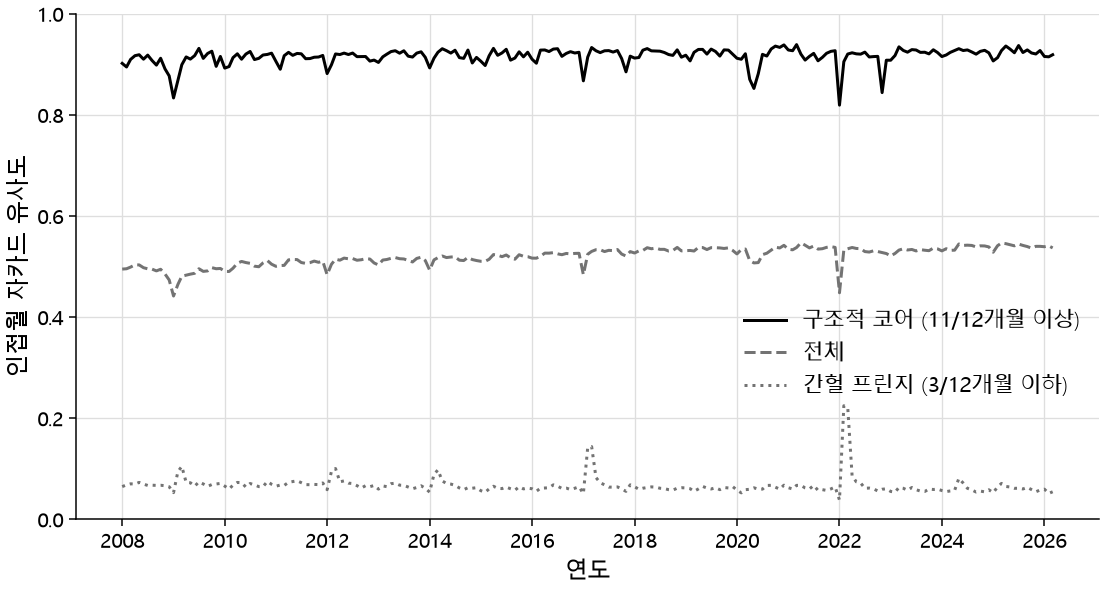

코어 자카드 평균 0.916  |  전체 0.520  |  프린지 0.067


In [10]:
# 그림 3 — 층위별 인접월 자카드
# 규격: 그림 5(semi_destinations)와 맞춤 — figsize (9.5, 5.2), lw 1.8, 흑백 선종류로 구분
fig, ax = plt.subplots(figsize=(9.5, 5.2))
d = ts.dropna(subset=['jac_core'])
ax.plot(d['date'], d['jac_core'], color='black', lw=1.8,
        label=f'구조적 코어 ({CORE_K}/12개월 이상)')
ax.plot(d['date'], d['jac_adj'], color='0.45', lw=1.8, ls='--', label='전체')
ax.plot(d['date'], d['jac_fringe'], color='0.45', lw=1.8, ls=':',
        label=f'간헐 프린지 ({FRINGE_K}/12개월 이하)')
ax.set_ylim(0, 1.0); ax.set_xlabel('연도'); ax.set_ylabel('인접월 자카드 유사도')
# 제목은 본문 캡션과 중복되므로 그림에 넣지 않는다
style_ax(ax)
ax.legend(loc='center right', bbox_to_anchor=(1.0, 0.33), frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/net_jaccard_layers.png"); plt.show()

# 본문 인용 수치
print(f"코어 자카드 평균 {d['jac_core'].mean():.3f}  |  전체 {d['jac_adj'].mean():.3f}"
      f"  |  프린지 {d['jac_fringe'].mean():.3f}")

### §III.4·§IV.2 근거 — 코어 자카드의 1월 저점과 HS 개정연도

코어 자카드가 1월에 낮아지는 원인을 검증한다. jac_core 월별 평균에서
**1월이 최저 달**(연초 재편)임을 확인하고, 그 1월 안에서 **개정연도(2012·2017·2022)와
비개정연도**를 비교한다. 개정연도 1월이 유독 낮으면(특히 2022·2017) 본문 §III.4의 "HS 개정" 서술이
성립한다. 대조로 전체 엣지 jac_adj의 월별 평균이 평탄함(§IV.2)을 함께 보여, 코어 층위에서만
1월 저점이 두드러짐을 드러낸다. 본문 표가 아니라 §III.4·§IV.2 서술의 근거로만 쓴다.

In [11]:
# ===== §III.4·§IV.2 근거: 코어 자카드의 1월 저점과 HS 개정연도 =====
c = ts.dropna(subset=['jac_core']).copy()
c['mon'] = c['ym'] % 100
c['yr']  = c['ym'] // 100

# (1) jac_core 월별(1~12월) 평균 -> 1월 저점 확인
mm  = c.groupby('mon')['jac_core'].mean()
mma = c.groupby('mon')['jac_adj'].mean()          # 대조: 전체 엣지(§IV.2)
print("jac_core 월별 평균(1~12월):")
print(mm.round(3).to_string())
print(f"  1월 {mm.loc[1]:.3f} vs 2~12월 {c.loc[c['mon']!=1,'jac_core'].mean():.3f}"
      f"  (월별평균 범위 {mm.min():.3f}~{mm.max():.3f})")
print(f"  대조 jac_adj 월별평균 범위 {mma.min():.3f}~{mma.max():.3f} (1월 {mma.loc[1]:.3f}) "
      f"-> 코어보다 평탄(§IV.2)")

# (2) 1월 안에서 개정연도(2012.2017.2022) vs 비개정연도
REV = [2012, 2017, 2022]
jan   = c[c['mon'] == 1]
rev_j = jan[jan['yr'].isin(REV)]['jac_core']
non_j = jan[~jan['yr'].isin(REV)]['jac_core']
print(f"\n1월 개정연도 평균 {rev_j.mean():.3f}(n={len(rev_j)}) vs "
      f"비개정연도 {non_j.mean():.3f}(n={len(non_j)}), 차 {rev_j.mean()-non_j.mean():+.3f}")
print(f"비개정 1월 분포: 평균 {non_j.mean():.3f}, sd {non_j.std():.3f}")
diag = []
for yr in REV:
    val = jan.loc[jan['yr']==yr, 'jac_core']
    if len(val):
        z = (val.iloc[0]-non_j.mean())/non_j.std()
        print(f"  {yr}.01: {val.iloc[0]:.3f}  (비개정1월 대비 z={z:+.2f})")
        diag.append({'개정연도':yr, 'jac_core_1월':round(val.iloc[0],3), 'z_vs_비개정1월':round(z,2)})
# 판정: 1월이 최저 달(연초 재편) + 그중 개정연도(특히 2022, 다음 2017)가 유독 낮음. 2012는 미검출.
#       -> 캡션은 원인을 개정 단독으로 두지 말고 '1월 재편 + 개정연도(특히 2022.2017)'로 서술.
pd.DataFrame(diag).to_csv("outputs/sec34_jaccore_january.csv", index=False, encoding='utf-8-sig')

jac_core 월별 평균(1~12월):
mon
1     0.896
2     0.906
3     0.922
4     0.922
5     0.918
6     0.920
7     0.927
8     0.916
9     0.917
10    0.922
11    0.912
12    0.917
  1월 0.896 vs 2~12월 0.918  (월별평균 범위 0.896~0.927)
  대조 jac_adj 월별평균 범위 0.505~0.524 (1월 0.505) -> 코어보다 평탄(§IV.2)

1월 개정연도 평균 0.856(n=3) vs 비개정연도 0.904(n=16), 차 -0.048
비개정 1월 분포: 평균 0.904, sd 0.021
  2012.01: 0.882  (비개정1월 대비 z=-1.07)
  2017.01: 0.867  (비개정1월 대비 z=-1.76)
  2022.01: 0.819  (비개정1월 대비 z=-4.07)


## 6. 그림 4 — 코어 금액/개수 비중

코어가 당월 엣지에서 차지하는 개수 비중과 금액 비중. 두 선의 간극이 이 논문의
핵심 시각 증거다. 검은 실선의 2012·2017·2022년 저하는 HS 개정에 따른 코드 구성 변화의
측정 효과이며, 2009년 저하도 대부분 같은 성격이다(§III.4에서 진단). 저하는 이 그림에 이미
나타나므로 별도 확대 그림을 만들지 않는다.

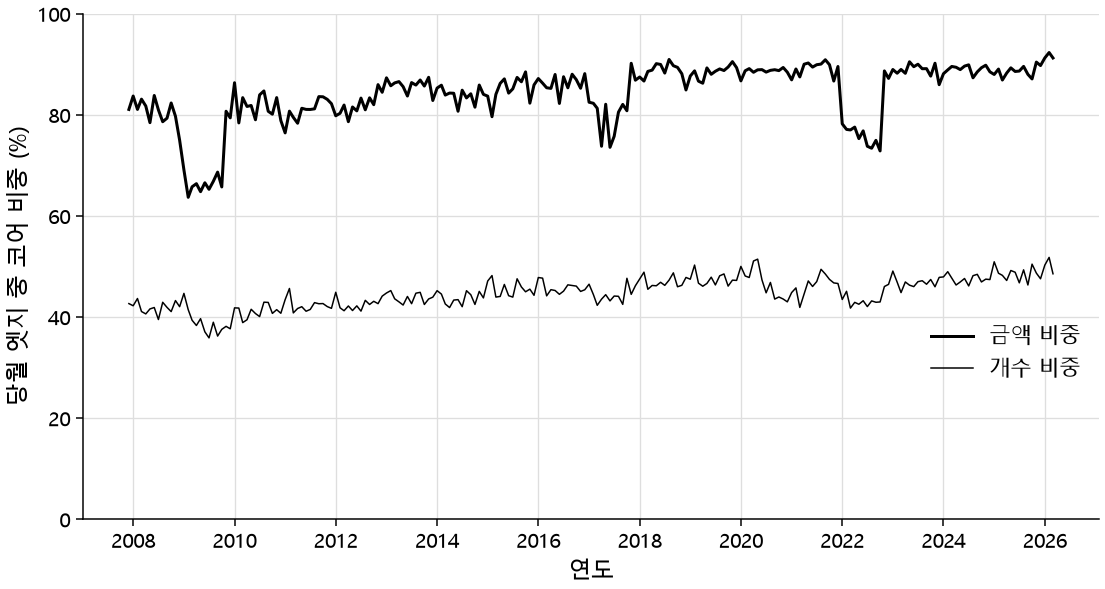

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
d = ts.dropna(subset=['core_share_value'])
ax.plot(d['date'], d['core_share_value']*100, color='black', lw=1.8, label='금액 비중')
ax.plot(d['date'], d['core_share_edges']*100, color='black', lw=0.9, ls='-', label='개수 비중')
ax.set_ylim(0, 100); ax.set_xlabel('연도')
ax.set_ylabel('당월 엣지 중 코어 비중 (%)')
# 제목은 본문 캡션과 중복되므로 그림에 넣지 않는다
style_ax(ax)
ax.legend(loc='center right', bbox_to_anchor=(1.0, 0.33), frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/net_core_share.png"); plt.show()

## 7. 표 1 — 코어 내부 금액 집중 (상위 1/5/10%)

코어 엣지를 금액 순으로 늘어놓고 상위 비율이 코어 금액에서 차지하는 몫. 두 시점
비교이므로 그림 대신 표로 제시한다(논문 V.1절).

In [13]:
def core_concentration(ym):
    core = core_at(ym)
    if not core: return None
    vm = val_maps[ym]
    vals = np.sort([vm[e] for e in core if e in vm])[::-1]
    tot = vals.sum(); n = len(vals)
    f = lambda p: vals[:max(1,int(n*p))].sum()/tot*100
    return dict(ym=ym, core_n=n, core_bil=tot/1e9,
                top1=f(.01), top5=f(.05), top10=f(.10))

tab1 = pd.DataFrame([core_concentration(y) for y in [200712, 202512]])
tab1 = tab1.round({'core_bil':1,'top1':1,'top5':1,'top10':1})
tab1.columns = ['연월','코어 엣지수','코어금액($B)','상위1%(%)','상위5%(%)','상위10%(%)']
print(tab1.to_string(index=False))
tab1.to_csv("outputs/table1_core_concentration.csv", index=False, encoding='utf-8-sig')

    연월  코어 엣지수  코어금액($B)  상위1%(%)  상위5%(%)  상위10%(%)
200712   21915      26.7     51.9     75.3      84.3
202512   34675      62.4     65.6     82.8      89.3


### §V.2 둘째 축 — 전체 대국 점유 추이

집중을 이끄는 둘째 축(상대국 구성 재편)의 근거. 반도체 4개 코드가 아니라 전체 엣지 집합
(수출 >$1,000)에서 연도별 대중국·대미 금액 점유를 계산한다. 시작·정점 연도와 미국의
연간 역전 여부를 함께 확인한다(논문 V.2절, §6과 대비).

In [14]:
# §V.2 둘째 축 — 전체 네트워크의 대국 점유 추이 (edf, 수출 >$1,000, 연간 합)
_cc = edf.assign(yr=edf['ym']//100).groupby(['yr','cty'])['v'].sum().reset_index()
_rows = []
for _y in range(2007, 2027):
    _g = _cc[_cc.yr == _y]
    if _g.empty: continue
    _tot = _g.v.sum()
    _cn = _g.loc[_g.cty=='CN','v'].sum()/_tot*100
    _us = _g.loc[_g.cty=='US','v'].sum()/_tot*100
    _lead = _g.sort_values('v', ascending=False).iloc[0]['cty']
    _rows.append({'연도':_y, '중국pct':round(_cn,1), '미국pct':round(_us,1),
                  '1위국':cmap.get(_lead,_lead)})
axis52 = pd.DataFrame(_rows)
print(axis52.to_string(index=False))
_pk = axis52.loc[axis52['중국pct'].idxmax()]
_a07 = axis52[axis52.연도==2007].iloc[0]; _a25 = axis52[axis52.연도==2025].iloc[0]
_rev = axis52.loc[axis52['미국pct'] > axis52['중국pct'], '연도'].tolist()
print(f"\n대중국 정점: {int(_pk['연도'])}년 {_pk['중국pct']}%")
print(f"2007년: 중국 {_a07['중국pct']}% · 미국 {_a07['미국pct']}%   /   2025년: 중국 {_a25['중국pct']}% · 미국 {_a25['미국pct']}%")
print("미국이 연간 기준 중국을 앞선 해:", _rev if _rev else "없음")
axis52.to_csv("outputs/sec52_country_axis.csv", index=False, encoding='utf-8-sig')

  연도  중국pct  미국pct 1위국
2007   22.1   12.3  중국
2008   21.7   11.0  중국
2009   23.9   10.4  중국
2010   25.1   10.7  중국
2011   24.2   10.1  중국
2012   24.5   10.7  중국
2013   26.1   11.1  중국
2014   25.4   12.3  중국
2015   26.0   13.3  중국
2016   25.1   13.4  중국
2017   24.8   12.0  중국
2018   26.8   12.0  중국
2019   25.1   13.5  중국
2020   25.9   14.5  중국
2021   25.3   14.9  중국
2022   22.8   16.1  중국
2023   19.7   18.3  중국
2024   19.5   18.7  중국
2025   18.4   17.3  중국
2026   19.5   18.7  중국

대중국 정점: 2018년 26.8%
2007년: 중국 22.1% · 미국 12.3%   /   2025년: 중국 18.4% · 미국 17.3%
미국이 연간 기준 중국을 앞선 해: 없음


## 8. 반도체 사례 (그림 5·6, 표 2)

반도체 주력 품목의 상대국 포트폴리오. 목적지 점유 이동은 시간 흐름이 핵심이므로
그림으로, 코어/프린지 분류는 단일 시점 분류이므로 표로 제시한다.

In [15]:
SEMI = {'8542323000':'복합구조칩IC','8542321010':'DRAM',
        '8542321030':'플래시','8542311000':'프로세서'}
sd = edf[edf['hs'].isin(SEMI)].copy()
print(f"반도체 엣지행 {len(sd):,}")

반도체 엣지행 25,783


### §VI.1 반도체 세번별 상대국 수

반도체 주력 4개 품목 코드가 각 시점에 몇 개 상대국으로 수출되는지(상대국 차수)를 센다.
"소수 상대국에 집중"(20~50개국)과 복합구조칩·DRAM의 시점별 변화를 재현한다(논문 VI.1절).

In [16]:
# §VI.1 반도체 세번별 상대국 수(수출 대상국 수) — 대표 시점 + 전 기간 범위
_reps = [200712, 201012, 201312, 201612, 201912, 202212, 202412, 202512]
_deg = {}
for _h, _nm in SEMI.items():
    _deg[_nm] = {str(_ym): sd[(sd['ym']==_ym) & (sd['hs']==_h)]['cty'].nunique() for _ym in _reps}
_degdf = pd.DataFrame(_deg).T          # 행=품목, 열=대표 시점
print("반도체 세번별 상대국 수 (대표 시점):")
print(_degdf.to_string())
print("\n품목별 월별 상대국 수 범위(전 기간):")
for _h, _nm in SEMI.items():
    _s = sd[sd['hs']==_h].groupby('ym')['cty'].nunique()
    print(f"  {_nm:10s}: {_s.min()}~{_s.max()}개국 (활성 {len(_s)}개월)")
_allrange = sd.groupby(['ym','hs'])['cty'].nunique()
print(f"\n4개 세번 전체 월별 상대국 수 범위: {_allrange.min()}~{_allrange.max()}개국")
_degdf.to_csv("outputs/sec61_semi_country_degree.csv", encoding='utf-8-sig')

반도체 세번별 상대국 수 (대표 시점):
         200712  201012  201312  201612  201912  202212  202412  202512
복합구조칩IC      11      21      22      24      31      32      31      30
DRAM         20      29      29      29      30      27      28      23
플래시          13      24      26      18      20      19      14      17
프로세서          0      47      48      51      44      43      44      44

품목별 월별 상대국 수 범위(전 기간):
  복합구조칩IC   : 10~36개국 (활성 231개월)
  DRAM      : 14~33개국 (활성 231개월)
  플래시       : 10~38개국 (활성 231개월)
  프로세서      : 39~59개국 (활성 207개월)

4개 세번 전체 월별 상대국 수 범위: 10~59개국


### 그림 5 — 반도체 목적지 금액점유 이동

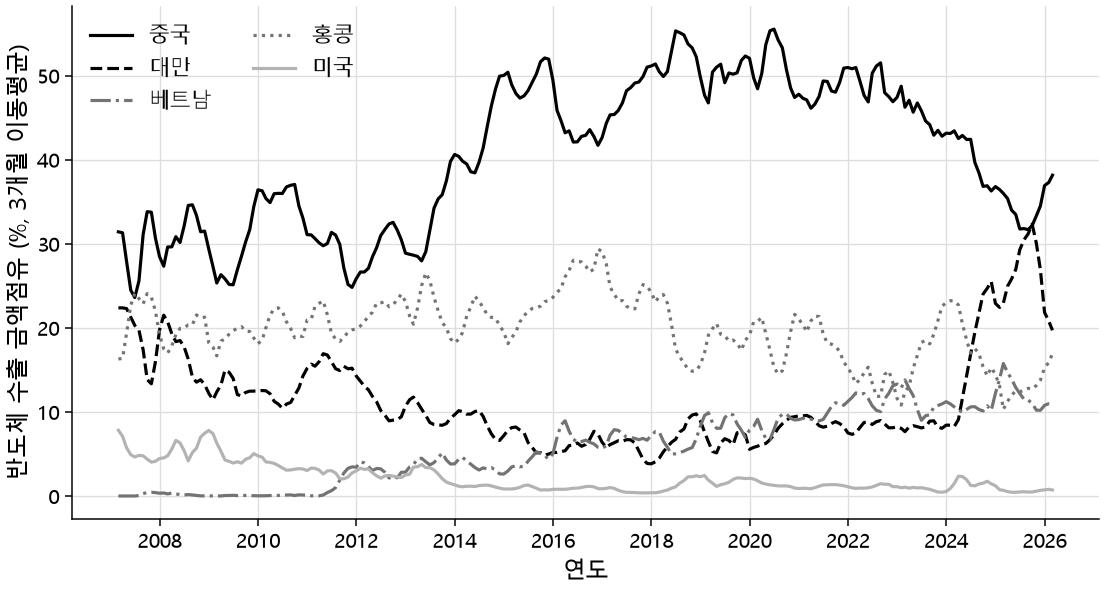

201912: 중국51% 대만6% 베트남6% 홍콩23% 미국2%
202512: 중국34% 대만23% 베트남11% 홍콩17% 미국1%


In [17]:
dest = ['CN','TW','VN','HK','US']
dest_ko = {'CN':'중국','TW':'대만','VN':'베트남','HK':'홍콩','US':'미국'}
# 흑백 구분: (선스타일, 회색조). 5개 목적지를 선모양+명도로 구별.
spec = {'CN':('-','black'), 'TW':('--','black'), 'VN':('-.','0.45'),
        'HK':(':','0.45'), 'US':('-','0.7')}
share_ts = []
for ym in MONTHS:
    g = sd[sd['ym']==ym]
    if len(g)==0: continue
    tot = g['v'].sum()
    row = {'ym':ym}
    gc = g.groupby('cty')['v'].sum()
    for c in dest:
        row[c] = gc.get(c, 0)/tot*100
    share_ts.append(row)
sdf = pd.DataFrame(share_ts)
sdf['date'] = pd.to_datetime(sdf['ym'].astype(str), format='%Y%m')

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for c in dest:
    ls, col = spec[c]
    ax.plot(sdf['date'], sdf[c].rolling(3).mean(), lw=1.9, ls=ls, color=col,
            label=dest_ko[c])
ax.set_xlabel('연도'); ax.set_ylabel('반도체 수출 금액점유 (%, 3개월 이동평균)')
# 제목은 본문 캡션과 중복되므로 그림에 넣지 않는다
style_ax(ax)
ax.legend(loc='upper left', frameon=False, ncol=2)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/semi_destinations.png"); plt.show()

# 본문 인용 시점값
for ym in [201912, 202512]:
    r = sdf[sdf['ym']==ym]
    if len(r):
        r=r.iloc[0]
        print(f"{ym}: " + " ".join(f"{dest_ko[c]}{r[c]:.0f}%" for c in dest))

### 표 2 — 반도체 코어/프린지 분류 (2025)

In [18]:
w = sd[(sd['ym']>=202501)&(sd['ym']<=202512)].copy()
w['edge'] = list(zip(w['hs'], w['cty']))
active = w.groupby('edge')['ym'].nunique()
emoney = w.groupby('edge')['v'].sum()
core_m = active>=CORE_K; fr_m = active<=FRINGE_K
tab2 = pd.DataFrame([
    {'층위':'구조적 코어(≥11/12)','엣지수':int(core_m.sum()),
     '엣지비율(%)':round(core_m.mean()*100,1),
     '금액점유(%)':round(emoney[core_m].sum()/emoney.sum()*100,1)},
    {'층위':'간헐 프린지(≤3/12)','엣지수':int(fr_m.sum()),
     '엣지비율(%)':round(fr_m.mean()*100,1),
     '금액점유(%)':round(emoney[fr_m].sum()/emoney.sum()*100,1)},
    {'층위':'전체','엣지수':len(active),'엣지비율(%)':100.0,'금액점유(%)':100.0},
])
print(tab2.to_string(index=False))
tab2.to_csv("outputs/table2_semi_core_fringe.csv", index=False, encoding='utf-8-sig')

            층위  엣지수  엣지비율(%)  금액점유(%)
구조적 코어(≥11/12)   98     56.0     99.9
 간헐 프린지(≤3/12)   46     26.3      0.0
            전체  175    100.0    100.0


### 그림 6 — 반도체 이분 네트워크 스냅숏 (2025.12)

반도체 주력 4품목과 그 상대국(금액 상위 10개국 + 기타)을 잇는 단일 시점 이분 네트워크다.
선 굵기는 당월 수출 금액, 선 종류는 지속성 층위(코어 실선 / 중간대 파선 / 프린지 점선)를
나타낸다. 층위는 논문 본문과 같은 정본 정의(당월 기준 최근 12개월; 3.3)로 판정하므로,
역년·반도체 부분집합으로 센 표 2의 코어/프린지 개수와는 정확히 일치하지 않을 수 있다.

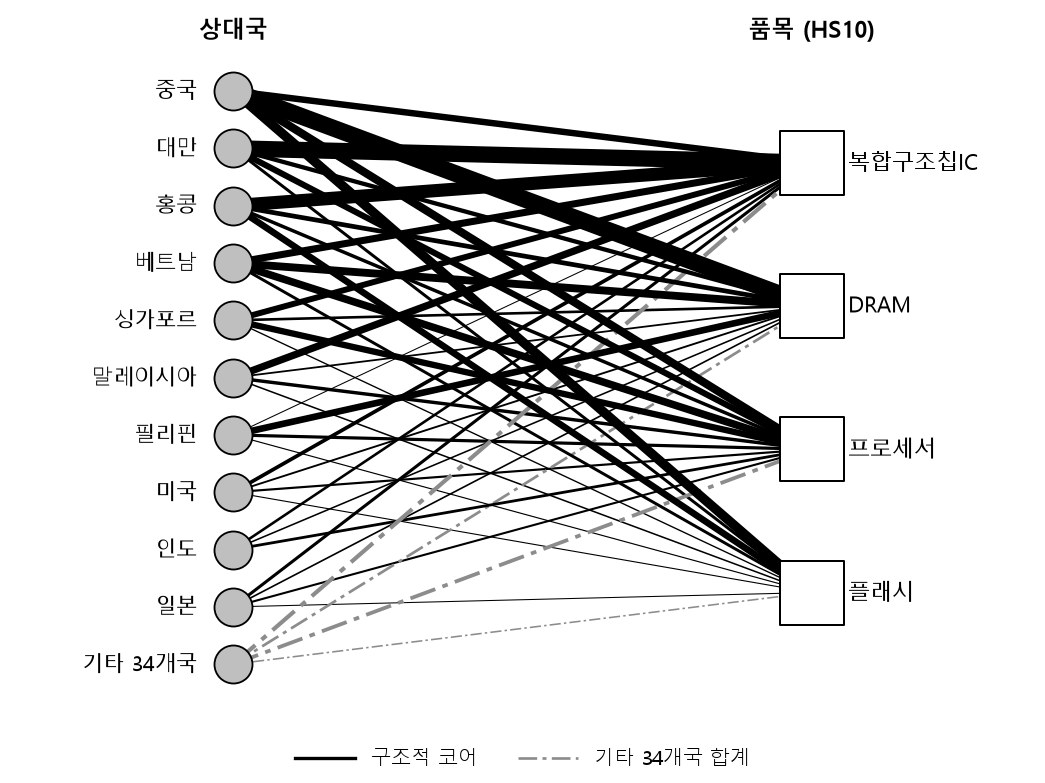

[202512] 반도체 4품목 합계 13.64십억$, 엣지 114개, 상대국 44개
  상위 10개국 금액 점유: 98.2%  |  기타 34개국: 1.8%
  코어: 엣지  97개 (85.1%), 금액  99.9%
  중간대: 엣지  15개 (13.2%), 금액   0.1%
  프린지: 엣지   2개 ( 1.8%), 금액   0.0%
  상위 10개국: 중국 33.9%, 대만 23.3%, 홍콩 16.7%, 베트남 11.0%, 싱가포르 4.7%, 말레이시아 3.9%, 필리핀 3.1%, 미국 0.8%, 인도 0.5%, 일본 0.5%


In [19]:
# 그림 6 — 반도체 이분 네트워크 스냅숏 (2025년 12월)
# 왼쪽=상대국(금액 상위 10개국 + 기타), 오른쪽=반도체 주력 4품목.
# 선 굵기 = 당월 수출 금액. 선 종류 = 코어 여부(실선/파선), 기타 노드의 합산선은 1점쇄선.
# 그림 제목은 넣지 않는다(본문 캡션과 중복).
from matplotlib.lines import Line2D

SNAP   = 202512
TOP_N  = 10

_g = sd[sd['ym'] == SNAP].copy()
if len(_g) == 0:
    raise ValueError(f"{SNAP} 반도체 엣지 없음")

_core   = core_at(SNAP)
_fringe = fringe_at(SNAP)

def _layer(e):
    if _core is not None and e in _core:     return 'core'
    if _fringe is not None and e in _fringe: return 'fringe'
    return 'mid'

_g['layer'] = _g['edge'].map(_layer)

# ---- 노드 선정 ----
_ctot = _g.groupby('cty')['v'].sum().sort_values(ascending=False)
_top  = list(_ctot.index[:TOP_N])
_rest = list(_ctot.index[TOP_N:])
_ptot = _g.groupby('hs')['v'].sum().sort_values(ascending=False)
_prod = list(_ptot.index)

_left_lab = [cmap.get(c, c) for c in _top]
if _rest:
    _left_lab.append(f"기타 {len(_rest)}개국")

# ---- 엣지 목록: (좌노드 idx, 우노드 idx, 금액, 종류) ----
_E = []
for _, r in _g[_g['cty'].isin(_top)].iterrows():
    _E.append((_top.index(r['cty']), _prod.index(r['hs']), r['v'], r['layer']))
if _rest:
    _ri = len(_top)
    for hs, v in _g[_g['cty'].isin(_rest)].groupby('hs')['v'].sum().items():
        _E.append((_ri, _prod.index(hs), v, 'rest'))

# ---- 좌표 ----
_lx, _rx = 0.22, 0.78
_ly = np.linspace(0.90, 0.10, len(_left_lab))
_py = np.linspace(0.80, 0.20, len(_prod))

# ---- 선 굵기: 제곱근 척도, 0.5~9.0 ----
_vmax = max(e[2] for e in _E)
def _lw(v):
    return 0.6 + 9.5 * (v / _vmax) ** 0.5

# 개별 엣지는 코어 여부만 구분(중간대·프린지는 금액이 0에 가까워 나눌 실익이 없다).
# 기타 노드의 선은 여러 층위를 합친 것이라 층위 표시 계열(실선·파선)과 다른 1점쇄선으로 둔다.
_DASHDOT = (0, (7, 2, 1.5, 2))
_style = {'core':  dict(color='black', ls='-'),
          'mid':   dict(color='0.55',  ls=(0, (5, 2))),
          'fringe':dict(color='0.55',  ls=(0, (5, 2))),
          'rest':  dict(color='0.55',  ls=_DASHDOT)}

fig, ax = plt.subplots(figsize=(9.0, 6.8))
for li, pi, v, lay in sorted(_E, key=lambda x: x[2]):      # 굵은 선이 위로
    ax.plot([_lx, _rx], [_ly[li], _py[pi]], lw=_lw(v),
            solid_capstyle='round', zorder=1, **_style[lay])

ax.scatter([_lx]*len(_left_lab), _ly, s=520, marker='o', facecolor='0.75',
           edgecolor='black', linewidth=1.1, zorder=2)
ax.scatter([_rx]*len(_prod), _py, s=1500, marker='s', facecolor='white',
           edgecolor='black', linewidth=1.2, zorder=2)
for _n, _y in zip(_left_lab, _ly):
    ax.text(_lx-0.035, _y, _n, ha='right', va='center', fontsize=12.5)
for _h, _y in zip(_prod, _py):
    ax.text(_rx+0.035, _y, SEMI[_h], ha='left', va='center', fontsize=13)
ax.text(_lx, 0.985, '상대국', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(_rx, 0.985, '품목 (HS10)', ha='center', va='center', fontsize=14, fontweight='bold')

ax.legend(handles=[Line2D([], [], color='black', ls='-',       lw=2.0, label='구조적 코어'),
                   Line2D([], [], color='0.55', ls=_DASHDOT,   lw=1.6, label='기타 34개국 합계')],
          loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2,
          frameon=False, fontsize=12, handlelength=3.0)
ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.02); ax.axis('off')
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/semi_bipartite.png", bbox_inches='tight'); plt.show()

# ---- 캡션·본문에 쓸 수치 ----
_T = _g['v'].sum()
print(f"[{SNAP}] 반도체 4품목 합계 {_T/1e9:.2f}십억$, 엣지 {len(_g)}개, 상대국 {_g['cty'].nunique()}개")
print(f"  상위 {TOP_N}개국 금액 점유: {_ctot.head(TOP_N).sum()/_T*100:.1f}%"
      f"  |  기타 {len(_rest)}개국: {_ctot.iloc[TOP_N:].sum()/_T*100:.1f}%")
for lay, nm in [('core','코어'), ('mid','중간대'), ('fringe','프린지')]:
    s = _g[_g['layer']==lay]
    print(f"  {nm}: 엣지 {len(s):3d}개 ({len(s)/len(_g)*100:4.1f}%), 금액 {s['v'].sum()/_T*100:5.1f}%")
print("  상위 10개국:", ", ".join(f"{cmap.get(c,c)} {_ctot[c]/_T*100:.1f}%" for c in _top))


## 9. 코어 저하 진단 (§III.4 근거 — 본문 표 아님)

저하를 동시대 기준선(인접 두 해 중앙값) 대비 %p로 잰다. 연속 유효 코드로 한정하면 큰 저하이
모두 사라지나, 비이벤트 월 잔존 저하 잡음(표준편차 2.0%p) 안이라 서로·평시와 구분되지 않는다.
필터는 지속성=결과변수와 상관돼 중립이 아니므로 잔존 저하은 하한으로만 읽는다. 저하가 코드
교체에서 옴은 자료기반 폐지·신설 코드 금액 비중(비동어반복)으로 뒷받침한다. 평시(2024.12)
대조와 창 정의별 비교(보조)도 둔다. 본문에는 싣지 않고 §III.4·§IV.3의 서술 근거로만 쓴다.

In [20]:
# ===== 코어 저하 진단 (§III.4 근거, 본문 표 아님): 그 무렵의 정상 수준 대비 저하(%p) + 잡음 척도 =====
_cy   = edf[edf['ym']//100 <= 2025]                       # 완결 연도만으로 코드 집합 판정
_yrs  = _cy.assign(_yr=_cy['ym']//100).groupby('hs')['_yr'].nunique()
_nyr  = (_cy['ym']//100).nunique()                        # 19
PERSIST = set(_yrs[_yrs == _nyr].index)                   # 19개 연도 모두 등장
esets_p = {ym: {e for e in s if e[1] in PERSIST} for ym, s in edge_sets.items()}
_corep = {}
def core_at_p(ym, need=CORE_K):
    if ym in _corep: return _corep[ym]
    win = last12(ym)
    if win[-1] not in esets_p: _corep[ym] = None; return None
    cnt = {}
    for w in win:
        for e in esets_p.get(w, set()): cnt[e] = cnt.get(e, 0) + 1
    _corep[ym] = {e for e, c in cnt.items() if c >= need}; return _corep[ym]
def _cs(ym, coreset, universe=None):
    vm = val_maps[ym]
    if universe is not None: vm = {e: v for e, v in vm.items() if e[1] in universe}
    tot = sum(vm.values())
    return sum(v for e, v in vm.items() if e in coreset)/tot*100 if tot else float('nan')

_full = {ym: _cs(ym, core_at(ym)) for ym in MONTHS if core_at(ym) is not None}
_pers = {ym: _cs(ym, core_at_p(ym), PERSIST) for ym in MONTHS if core_at_p(ym) is not None}
_mk = [m for m in MONTHS if m in _full]
# 전기간 평균 (§IV.3 근거): 전체 계열은 개정 착시 저하를 포함, 연속 유효 코드는 편의 없음
print(f"코어 금액비중 전기간 평균: 전체(HS10) {np.mean(list(_full.values())):.1f}%  |  연속 유효 코드 {np.mean(list(_pers.values())):.1f}%")
def _base(series, year):          # 동시대 기준선 = 인접 두 해 월별 중앙값 (진단표와 잡음이 공통 사용)
    vals = [series[m] for m in series if m//100 in (year-1, year+1)]
    return float(np.median(vals)) if vals else float('nan')
rows = []
for ym, lab in [(200906,'2009 금융위기'),(201206,'2012 HS개정'),(201706,'2017 HS개정'),
                (202004,'2020 코로나'),(202206,'2022 HS개정'),(202412,'2024.12 평시')]:
    yr = ym//100; bF = _base(_full, yr); bP = _base(_pers, yr)
    rows.append({'이벤트':lab, '저하월':ym, '전체(%)':round(_full[ym],1), '기준선(%)':round(bF,1),
                 '저하(%p)':round(bF-_full[ym],1), '연속코드잔존저하(%p)':round(bP-_pers[ym],1)})
tab1 = pd.DataFrame(rows)
print(f"전 기간 등장 코드: 전체 HS10 {edf['hs'].nunique():,} 중 {len(PERSIST):,}개 ({_nyr}/{_nyr}년 등장)")
print(tab1.to_string(index=False))
tab1.to_csv("outputs/table1_drop_diagnosis.csv", index=False, encoding='utf-8-sig')

# 잡음 척도: 진단표와 '동일한 인접 두 해 기준선'으로 잰 비이벤트 월 연속코드 잔존 저하 분포
# (제외를 개정연도까지 넓힌 것은 순환적이라, 최소 제외 버전도 병기)
def _noise(exclude_years):
    r = []
    for ym in _mk:
        if ym//100 in exclude_years: continue
        b = _base(_pers, ym//100)
        if not np.isnan(b): r.append(b - _pers[ym])
    return np.array(r)
print("\n비이벤트 월 잔존저하 분포 (인접 두 해 기준선, 진단표와 동일 척도):")
for _lab, _exc in [("개정+위기 제외", {2008,2009,2012,2017,2020,2022}),
                   ("최소 제외(2009·2020만)", {2009,2020})]:
    r = _noise(_exc)
    print(f"  [{_lab}] n={len(r)}: 표준편차 {r.std():.2f}%p, 90% 구간 [{np.percentile(r,5):.2f}, {np.percentile(r,95):.2f}]%p")
print("  -> 진단표의 잔존저하(2009 1.1 등)은 모두 이 잡음 안. 어느 이벤트도 잡음 넘는 실제 잔존 저하 없음.")

# ===== 자료기반 코드 교체(비동어반복): 폐지·신설 금액 비중 =====
_first = edf.groupby('hs')['ym'].min()//100
_last  = edf.groupby('hs')['ym'].max()//100
print("\n개정별 코드 교체 금액 비중 (자료상 first/last appearance 기준):")
for R, pre_m, post_m in [(2012,201112,201206),(2017,201612,201706),(2022,202112,202206)]:
    vm=val_maps[pre_m]; disc=sum(v for e,v in vm.items() if _last.get(e[1],9999)<=R-1)/sum(vm.values())*100
    vm2=val_maps[post_m]; new=sum(v for e,v in vm2.items() if _first.get(e[1],0)>=R)/sum(vm2.values())*100
    print(f"  {R} 개정: 폐지코드 금액비중({pre_m}) {disc:.1f}% | 신설코드 금액비중({post_m}) {new:.1f}%")
print("  주의: 폐지 비중과 저하 크기는 단조 대응 아님(단월 값 vs 12개월 창 단절, 시간범위 상이).")
print("  (폐지 코드는 개정 전 코어일 수 있어 비동어반복; 신설이 코어에 못 드는 것만 정의상 강제)")

# ===== (보조) 창 정의 강건성: 저하가 특정 창 길이의 산물이 아님 =====
def core_generic(ym, back, fwd, need):
    if step(ym, back) not in edge_sets: return None
    if fwd>0 and step(ym,-fwd) not in edge_sets: return None
    cnt={}
    for k in range(-fwd, back+1):
        for e in edge_sets.get(step(ym,k), set()): cnt[e]=cnt.get(e,0)+1
    return {e for e,c in cnt.items() if c>=need}
def core_split(ym):
    if step(ym,12) not in edge_sets: return None
    cnt={}
    for k in range(1,13):
        for e in edge_sets.get(step(ym,k),set()): cnt[e]=cnt.get(e,0)+1
    return {e for e,c in cnt.items() if c>=11}
def mshare(ym, core):
    vm=val_maps.get(ym,{})
    if not vm or core is None: return float('nan')
    return sum(v for e,v in vm.items() if e in core)/sum(vm.values())*100
appx=pd.DataFrame([dict(연월=ym,
    기준=round(mshare(ym,core_generic(ym,11,0,11)),1),
    대칭=round(mshare(ym,core_generic(ym,6,6,12)),1),
    이동창24=round(mshare(ym,core_generic(ym,23,0,22)),1),
    분리=round(mshare(ym,core_split(ym)),1)) for ym in [200906,201706,202206,202412]])
print("\n(보조) 창 정의별 비교(절대 %):")
print(appx.to_string(index=False))
appx.to_csv("outputs/appendix_window_robust.csv", index=False, encoding='utf-8-sig')

코어 금액비중 전기간 평균: 전체(HS10) 84.3%  |  연속 유효 코드 85.3%


전 기간 등장 코드: 전체 HS10 13,788 중 5,130개 (19/19년 등장)
       이벤트    저하월  전체(%)  기준선(%)  저하(%p)  연속코드잔존저하(%p)
 2009 금융위기 200906   66.6    81.4    14.8           1.1
 2012 HS개정 201206   80.8    83.6     2.8           0.4
 2017 HS개정 201706   73.6    87.8    14.2          -0.7
  2020 코로나 202004   88.4    89.2     0.8          -0.0
 2022 HS개정 202206   76.8    89.3    12.5           1.1
2024.12 평시 202412   88.5    89.0     0.5          -1.9

비이벤트 월 잔존저하 분포 (인접 두 해 기준선, 진단표와 동일 척도):
  [개정+위기 제외] n=148: 표준편차 1.96%p, 90% 구간 [-2.55, 3.17]%p
  [최소 제외(2009·2020만)] n=196: 표준편차 2.12%p, 90% 구간 [-3.54, 3.33]%p
  -> 진단표의 잔존저하(2009 1.1 등)은 모두 이 잡음 안. 어느 이벤트도 잡음 넘는 실제 잔존 저하 없음.



개정별 코드 교체 금액 비중 (자료상 first/last appearance 기준):
  2012 개정: 폐지코드 금액비중(201112) 3.4% | 신설코드 금액비중(201206) 3.0%


  2017 개정: 폐지코드 금액비중(201612) 3.8% | 신설코드 금액비중(201706) 6.0%
  2022 개정: 폐지코드 금액비중(202112) 13.8% | 신설코드 금액비중(202206) 13.3%
  주의: 폐지 비중과 저하 크기는 단조 대응 아님(단월 값 vs 12개월 창 단절, 시간범위 상이).
  (폐지 코드는 개정 전 코어일 수 있어 비동어반복; 신설이 코어에 못 드는 것만 정의상 강제)



(보조) 창 정의별 비교(절대 %):
    연월   기준   대칭  이동창24   분리
200906 66.6 78.7   61.7 65.4
201706 73.6 78.3   71.4 73.4
202206 76.8 88.7   75.0 76.5
202412 88.5 88.5   87.5 88.2


---
## 산출물 요약

**그림** (img/, 600dpi)
- net_growth.png — 그림 1 (네트워크 규모 성장)
- net_core_share.png — 그림 2 (코어 금액/개수 비중)
- semi_destinations.png — 그림 3 (반도체 목적지 금액점유 이동)
- semi_bipartite.png — 그림 4 (반도체 이분 네트워크 스냅숏)

**본문 표** (outputs/)
- table1_core_concentration.csv — 표 1 (코어 내부 금액집중)
- table2_semi_core_fringe.csv — 표 2 (반도체 코어/프린지)

**본문 서술 근거 CSV** (outputs/, 표 아님)
- sec31_threshold_sensitivity.csv — §III.1 임계값 민감도
- sec34_jaccore_january.csv — §III.4 코어 자카드 1월 저점
- table1_drop_diagnosis.csv — §III.4 코어 저하 진단
- appendix_window_robust.csv — §III.4 보조 (창 정의별 비교)
- sec61_semi_country_degree.csv — §VI.1 반도체 세번별 상대국 수
- sec52_country_axis.csv — §V.2 대국 점유 추이

표와 그림의 중복은 제거했다. 규모·코어비중·목적지이동·이분 스냅숏은 그림으로,
코어 내부집중·반도체 층위분류는 표로, 나머지 서술 근거는 CSV로 남긴다.